In [10]:
import sys

sys.path.append("..")

import torch
import matplotlib.pyplot as plt
import numpy as np

from src.paths import Paths
from src.utils import (
    get_device,
    tensor_to_img,
    plot_image,
    initialize_resnet18,
    load_model_weights,
)
from src.data_manager import DataManager
from src.perturbations import Perturbations
from src import config
from src.explainers import IGExplainer, OcclusionExplainer
from src.xai_experiment import XAIExperiment

## Konfiguracja ogólna

In [11]:
dataset_name = "mnist"
sigma = 0.8

device = get_device()
empty_model = initialize_resnet18(pretrained=False)

paths = Paths()

model = load_model_weights(empty_model, paths.MNIST_MODEL, device)

data_manager = DataManager(paths.DATA_DIR)

test_data = data_manager.get_test_dataset(
    dataset_name=dataset_name,
    download=False,
)

class_names = data_manager.get_class_names(dataset_name=dataset_name)

perturbations = Perturbations(
    model=model,
    device=device,
)

max_examples_per_class = 10

clean_examples = {class_id: [] for class_id in range(len(class_names))}

for image, label in test_data:
    if len(clean_examples[label]) >= max_examples_per_class:
        continue

    tensor = image.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(tensor)
        pred = output.argmax(dim=1).item()

    if pred == label:
        clean_examples[label].append(image)

    if all(
        len(clean_examples[class_id]) >= max_examples_per_class
        for class_id in clean_examples
    ):
        break

clean_examples_vis = {
    class_id: clean_examples[class_id][0] for class_id in clean_examples
}

## Konfiguracja IG

In [12]:
ig_explainer = IGExplainer(model=model, device=device, config=config.IGConfig())
ig_experiment = XAIExperiment(
    model=model,
    device=device,
    class_names=class_names,
    clean_examples=clean_examples,
    explainer=ig_explainer,
    perturbations=perturbations,
)
ig_experiment_vis = XAIExperiment(
    model=model,
    device=device,
    class_names=class_names,
    clean_examples=clean_examples_vis,
    explainer=ig_explainer,
    perturbations=perturbations,
)

ig_classes = ig_experiment_vis.selected_classes

all_ig_attrs = []
for class_id in ig_classes:
    clean_tensor = ig_experiment_vis.get_clean_tensor(class_id)
    noised_tensor = ig_experiment_vis.get_perturbed_tensor(
        clean_tensor=clean_tensor,
        class_id=class_id,
        perturbation_type="gaussian",
        value=sigma,
    )

    clean_attr = ig_experiment_vis.explainer.explain(
        input_tensor=clean_tensor, target_class=class_id
    )["abs"]

    noised_attr = ig_experiment_vis.explainer.explain(
        input_tensor=noised_tensor, target_class=class_id
    )["abs"]

    all_ig_attrs.append(clean_attr)
    all_ig_attrs.append(noised_attr)

ig_vmin = 0
ig_vmax = np.percentile([attr.flatten() for attr in all_ig_attrs], 99)


## Czyste obrazy

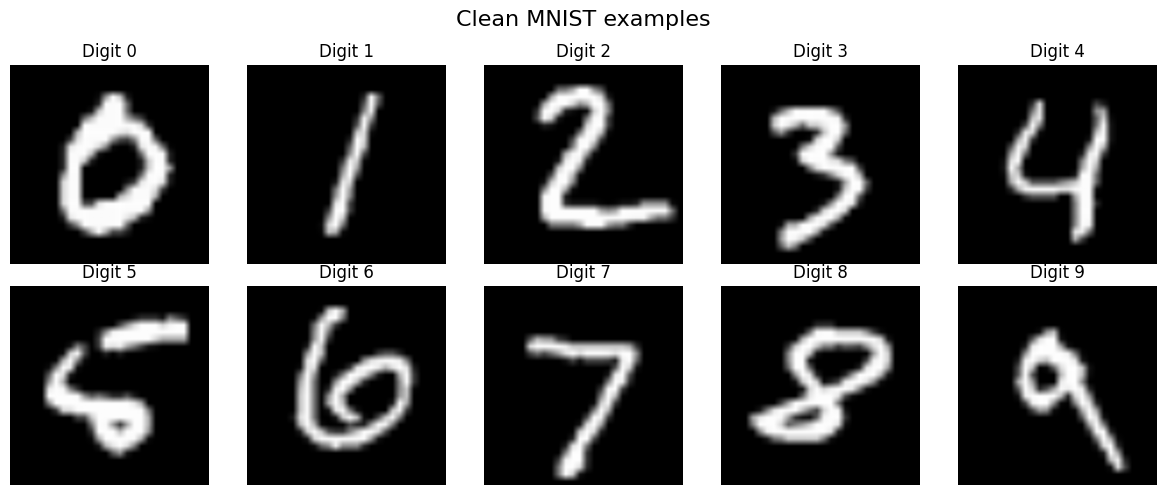

In [13]:
fig, axes = plt.subplots(
    2,
    5,
    figsize=(12, 5),
)

fig.suptitle("Clean MNIST examples", fontsize=16)

for idx, class_id in enumerate(ig_classes):
    row, col = divmod(idx, 5)

    clean_tensor = ig_experiment_vis.get_clean_tensor(class_id, to_device=False)

    plot_image(
        axes[row, col],
        tensor_to_img(clean_tensor),
        title=f"Digit {ig_experiment_vis.class_names[class_id]}",
        cmap="gray",
    )

plt.tight_layout()
plt.show()

## IG dla niezaszumionych danych

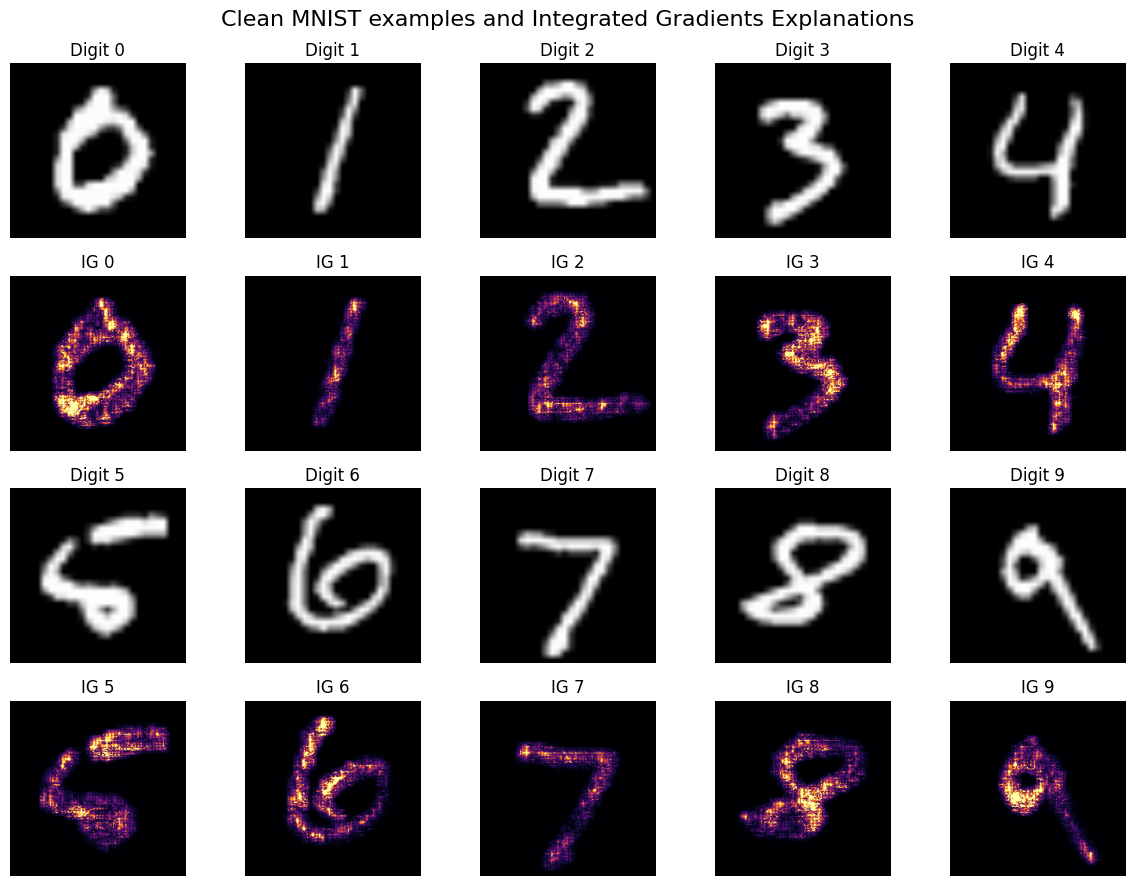

In [5]:
fig, axes = plt.subplots(
    4,
    5,
    figsize=(12, 9),
)

fig.suptitle(
    "Clean MNIST examples and Integrated Gradients Explanations",
    fontsize=16,
)

for idx, class_id in enumerate(ig_classes):
    block, col = divmod(idx, 5)

    clean_tensor = ig_experiment_vis.get_clean_tensor(class_id)
    clean_img = tensor_to_img(clean_tensor)

    attr_ig = ig_experiment_vis.explainer.explain(
        input_tensor=clean_tensor,
        target_class=class_id,
    )["abs"]

    plot_image(
        axes[block * 2, col],
        clean_img,
        title=f"Digit {class_names[class_id]}",
        cmap="gray",
    )

    plot_image(
        axes[block * 2 + 1, col],
        attr_ig,
        title=f"IG {class_names[class_id]}",
        cmap="inferno",
        vmin=ig_vmin,
        vmax=ig_vmax,
    )

plt.tight_layout()
plt.show()

## Szum Gaussa - prezentacja

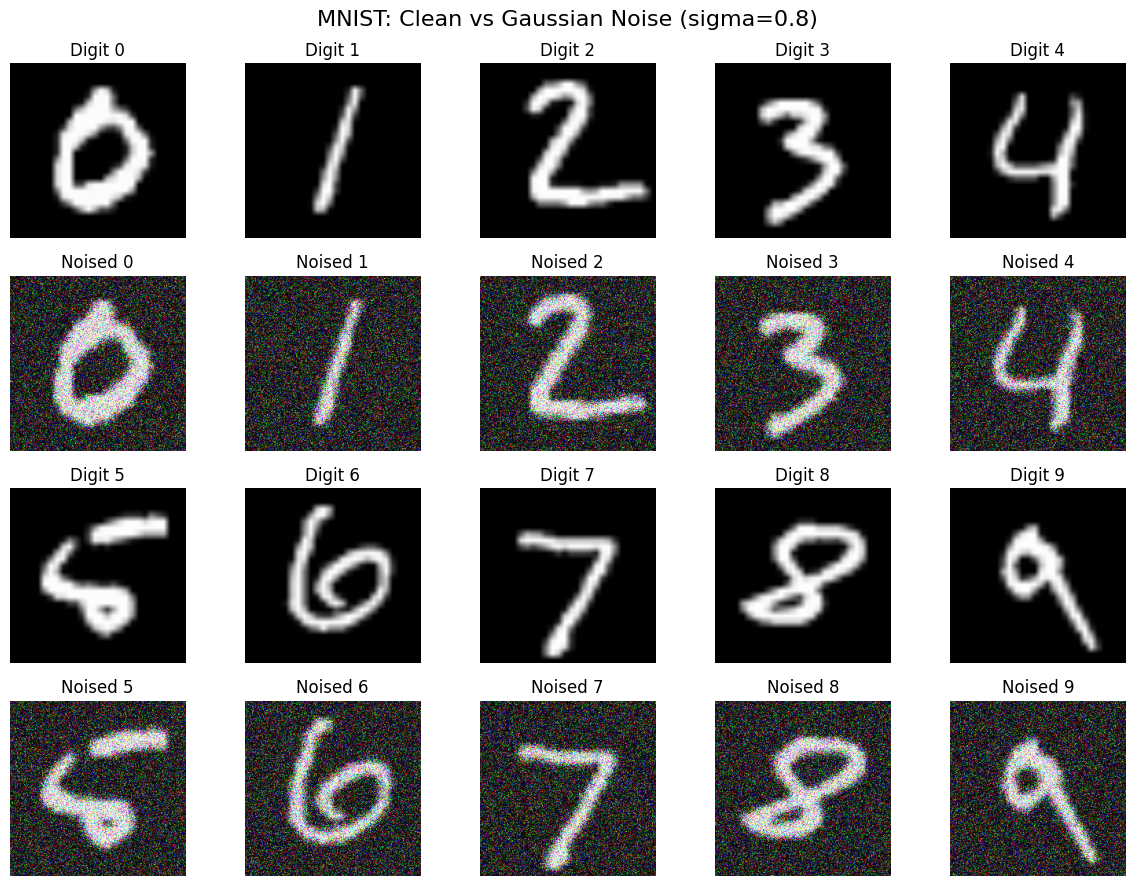

In [6]:
fig, axes = plt.subplots(
    4,
    5,
    figsize=(12, 9),
)

fig.suptitle(
    f"MNIST: Clean vs Gaussian Noise (sigma={sigma})",
    fontsize=16,
)

for idx, class_id in enumerate(ig_classes):
    block, col = divmod(idx, 5)

    clean_tensor = ig_experiment_vis.get_clean_tensor(
        class_id,
        to_device=False,
    )

    noised_tensor = perturbations.gaussian(
        input_tensor=clean_tensor,
        sigma=sigma,
    )

    plot_image(
        axes[block * 2, col],
        tensor_to_img(clean_tensor),
        title=f"Digit {class_names[class_id]}",
        cmap="gray",
    )

    plot_image(
        axes[block * 2 + 1, col],
        tensor_to_img(noised_tensor),
        title=f"Noised {class_names[class_id]}",
        cmap="gray",
    )

plt.tight_layout()
plt.show()

## IG danych niezaszumionych oraz zaszumionych

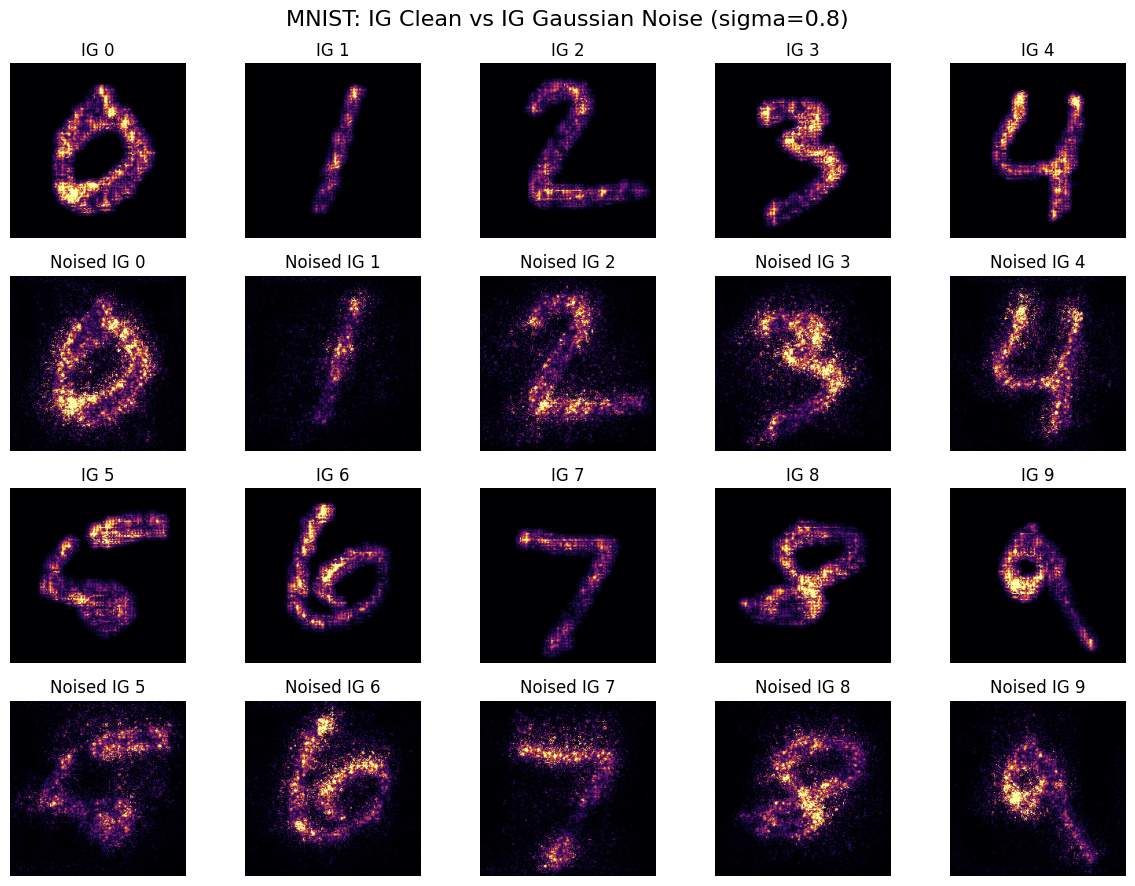

In [7]:
fig, axes = plt.subplots(
    4,
    5,
    figsize=(12, 9),
)

fig.suptitle(
    f"MNIST: IG Clean vs IG Gaussian Noise (sigma={sigma})",
    fontsize=16,
)

for idx, class_id in enumerate(ig_classes):
    block, col = divmod(idx, 5)

    clean_tensor = ig_experiment_vis.get_clean_tensor(class_id)

    noised_tensor = ig_experiment_vis.perturbations.gaussian(
        input_tensor=clean_tensor,
        sigma=sigma,
    )

    clean_attr = ig_experiment_vis.explainer.explain(
        input_tensor=clean_tensor,
        target_class=class_id,
    )["abs"]

    noised_attr = ig_experiment_vis.explainer.explain(
        input_tensor=noised_tensor,
        target_class=class_id,
    )["abs"]

    plot_image(
        axes[block * 2, col],
        clean_attr,
        title=f"IG {class_names[class_id]}",
        cmap="inferno",
        vmin=ig_vmin,
        vmax=ig_vmax,
    )

    plot_image(
        axes[block * 2 + 1, col],
        noised_attr,
        title=f"Noised IG {class_names[class_id]}",
        cmap="inferno",
        vmin=ig_vmin,
        vmax=ig_vmax,
    )

plt.tight_layout()
plt.show()

## Cosine Similarity oraz TopK IoU (IG)

In [17]:
df_similarity = ig_experiment.run_similarity_metrics(
    perturbation_type="gaussian",
    values=config.ExperimentConfig().gaussian_sigmas,
)

display(
    ig_experiment.make_pivot(
        df_similarity,
        "CosineSimilarity",
    ).round(3)
)

display(
    ig_experiment.make_pivot(
        df_similarity,
        "TopK_IoU",
    ).round(3)
)

display(ig_experiment.summarize_similarity(df_similarity).round(3))

Processing gaussian=0.01


KeyboardInterrupt: 

## Deletion AUC (IG)

In [19]:
df_deletion = ig_experiment.run_deletion_auc(
    perturbation_type="gaussian",
    values=config.ExperimentConfig().gaussian_sigmas,
)

display(
    ig_experiment.make_pivot(
        df_deletion,
        "DeletionAUC_Perturbed",
    ).round(3)
)

display(ig_experiment.summarize_deletion(df_deletion).round(3))

Processing gaussian=0.01
Processing gaussian=0.05
Processing gaussian=0.1
Processing gaussian=0.5


ClassName,0,1,2,3,4,5,6,7,8,9
Value,,,,,,,,,,
0.01,0.713,0.987,0.447,0.621,0.503,0.573,0.248,0.829,0.726,0.307
0.05,0.750,0.987,0.402,0.415,0.460,0.235,0.131,0.903,0.598,0.302
0.10,0.613,0.978,0.260,0.175,0.265,0.375,0.100,0.917,0.464,0.185
0.50,0.235,0.851,0.078,0.026,0.067,0.057,0.050,0.147,0.059,0.030


,Value,CleanAUCMean,CleanAUCStd,PerturbedAUCMean,PerturbedAUCStd,CleanTargetConfidenceMean,PerturbedTargetConfidenceMean,PredictionChanges
0,0.01,0.344,0.262,0.595,0.230,0.999,0.999,0
1,0.05,0.344,0.262,0.518,0.285,0.999,0.998,0
2,0.10,0.344,0.262,0.433,0.310,0.999,0.998,0
3,0.50,0.344,0.262,0.160,0.251,0.999,0.970,0


## Konfiguracja Occlusion

In [9]:
occ_explainer = OcclusionExplainer(
    model=model, device=device, config=config.OcclusionConfig(), dataset=dataset_name
)
occ_experiment = XAIExperiment(
    model=model,
    device=device,
    class_names=class_names,
    clean_examples=clean_examples,
    explainer=occ_explainer,
    perturbations=perturbations,
)
occ_experiment_vis = XAIExperiment(
    model=model,
    device=device,
    class_names=class_names,
    clean_examples=clean_examples_vis,
    explainer=occ_explainer,
    perturbations=perturbations,
)

occ_classes = occ_experiment_vis.selected_classes

all_occ_attrs = []
for class_id in occ_classes:
    clean_tensor = occ_experiment_vis.get_clean_tensor(class_id)
    noised_tensor = occ_experiment_vis.get_perturbed_tensor(
        clean_tensor=clean_tensor,
        class_id=class_id,
        perturbation_type="gaussian",
        value=sigma,
    )

    clean_attr = occ_experiment_vis.explainer.explain(
        input_tensor=clean_tensor, target_class=class_id
    )["raw"]

    noised_attr = occ_experiment_vis.explainer.explain(
        input_tensor=noised_tensor, target_class=class_id
    )["raw"]

    all_occ_attrs.append(clean_attr)
    all_occ_attrs.append(noised_attr)

occ_vmin = min(attr.min() for attr in all_occ_attrs)
occ_vmax = max(attr.max() for attr in all_occ_attrs)


## Occlusion dla niezaszumionych danych

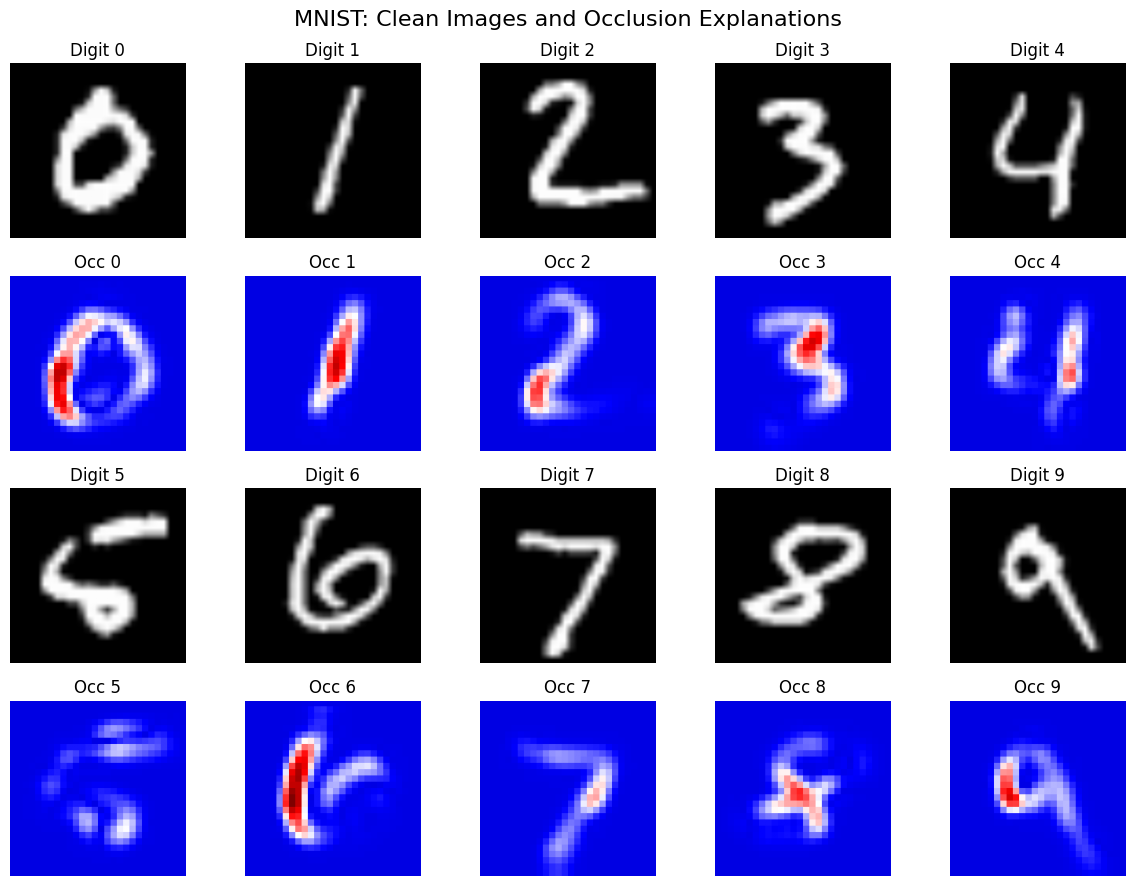

In [14]:
fig, axes = plt.subplots(
    4,
    5,
    figsize=(12, 9),
)

fig.suptitle(
    "MNIST: Clean Images and Occlusion Explanations",
    fontsize=16,
)

for idx, class_id in enumerate(occ_classes):
    block, col = divmod(idx, 5)

    clean_tensor = occ_experiment_vis.get_clean_tensor(class_id)

    attr_occ = occ_experiment_vis.explainer.explain(
        input_tensor=clean_tensor,
        target_class=class_id,
    )["abs"]

    plot_image(
        axes[block * 2, col],
        tensor_to_img(clean_tensor),
        title=f"Digit {occ_experiment_vis.class_names[class_id]}",
        cmap="gray",
    )

    plot_image(
        axes[block * 2 + 1, col],
        attr_occ,
        title=f"Occ {occ_experiment_vis.class_names[class_id]}",
        cmap="seismic",
        vmin=occ_vmin,
        vmax=occ_vmax,
    )

plt.tight_layout()
plt.show()

## Occlusion danych niezaszumionych oraz zaszumionych

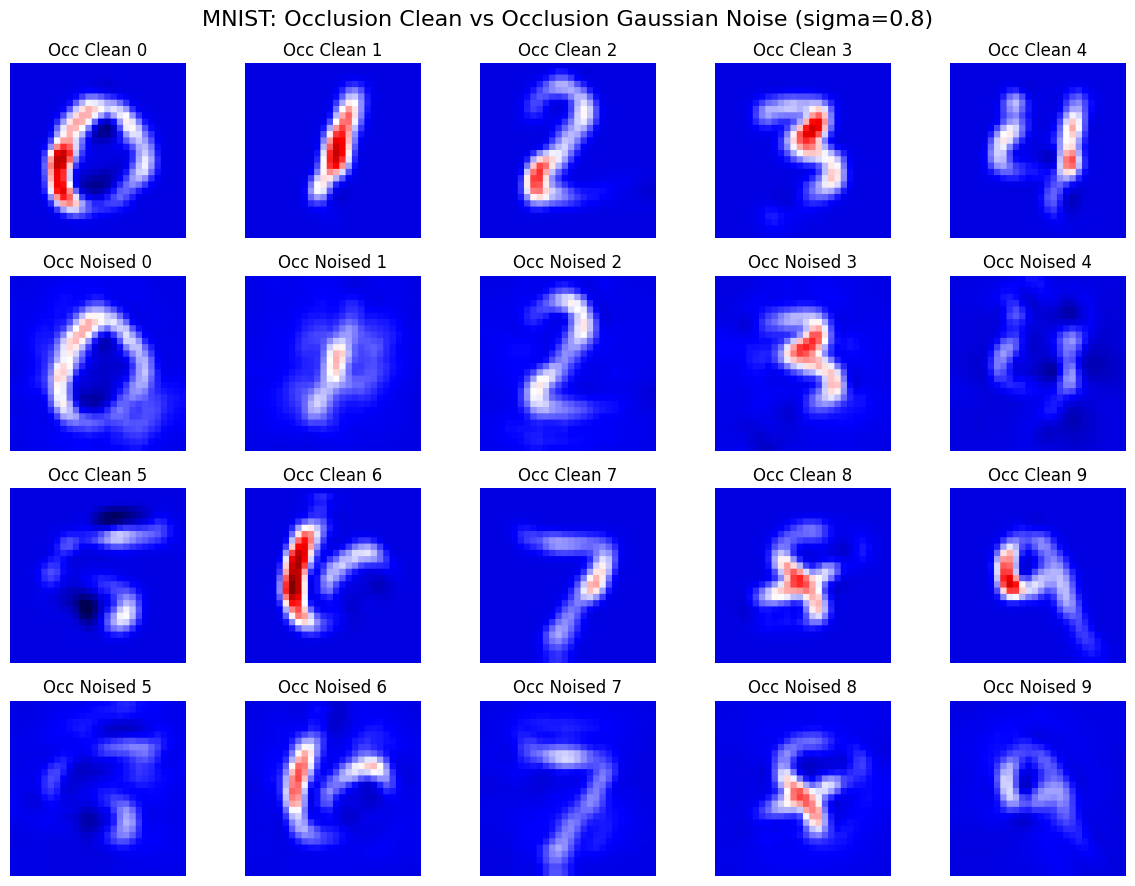

In [15]:
fig, axes = plt.subplots(
    4,
    5,
    figsize=(12, 9),
)

fig.suptitle(
    f"MNIST: Occlusion Clean vs Occlusion Gaussian Noise (sigma={sigma})",
    fontsize=16,
)

for idx, class_id in enumerate(occ_classes):
    block, col = divmod(idx, 5)

    clean_tensor = occ_experiment_vis.get_clean_tensor(class_id)

    noised_tensor = occ_experiment_vis.perturbations.gaussian(
        input_tensor=clean_tensor,
        sigma=sigma,
    )

    attr_occ_clean = occ_experiment_vis.explainer.explain(
        input_tensor=clean_tensor,
        target_class=class_id,
    )["raw"]

    attr_occ_noised = occ_experiment_vis.explainer.explain(
        input_tensor=noised_tensor,
        target_class=class_id,
    )["raw"]

    plot_image(
        axes[block * 2, col],
        attr_occ_clean,
        title=f"Occ Clean {occ_experiment_vis.class_names[class_id]}",
        cmap="seismic",
        vmin=occ_vmin,
        vmax=occ_vmax,
    )

    plot_image(
        axes[block * 2 + 1, col],
        attr_occ_noised,
        title=f"Occ Noised {occ_experiment_vis.class_names[class_id]}",
        cmap="seismic",
        vmin=occ_vmin,
        vmax=occ_vmax,
    )

plt.tight_layout()
plt.show()

## Cosine Similarity oraz TopK IoU (Occlusion)

In [23]:
df_occ_similarity = occ_experiment.run_similarity_metrics(
    perturbation_type="gaussian",
    values=config.ExperimentConfig().gaussian_sigmas,
)

display(
    occ_experiment.make_pivot(
        df_occ_similarity,
        "CosineSimilarity",
    ).round(3)
)

display(
    occ_experiment.make_pivot(
        df_occ_similarity,
        "TopK_IoU",
    ).round(3)
)

display(occ_experiment.summarize_similarity(df_occ_similarity).round(3))

Processing gaussian=0.01
Processing gaussian=0.05
Processing gaussian=0.1
Processing gaussian=0.5


ClassName,0,1,2,3,4,5,6,7,8,9
Value,,,,,,,,,,
0.01,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
0.05,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
0.10,0.999,0.999,0.999,1.000,0.998,0.999,0.999,0.999,0.999,0.999
0.50,0.968,0.951,0.970,0.984,0.957,0.909,0.975,0.939,0.977,0.969


ClassName,0,1,2,3,4,5,6,7,8,9
Value,,,,,,,,,,
0.01,0.993,0.992,0.993,0.992,0.991,0.995,0.992,0.997,0.993,0.993
0.05,0.965,0.990,0.985,0.985,0.985,0.960,0.975,0.985,0.972,0.985
0.10,0.936,0.965,0.941,0.975,0.950,0.894,0.960,0.975,0.960,0.975
0.50,0.786,0.926,0.858,0.926,0.836,0.587,0.836,0.746,0.815,0.844


,Value,CosineMean,CosineStd,TopKIoUMean,TopKIoUStd
0,0.01,1.000,0.000,0.993,0.002
1,0.05,1.000,0.000,0.978,0.010
2,0.10,0.999,0.000,0.953,0.025
3,0.50,0.960,0.022,0.816,0.098


## Deletion AUC (Occlusion)

In [24]:
df_occ_deletion = occ_experiment.run_deletion_auc(
    perturbation_type="gaussian",
    values=config.ExperimentConfig().gaussian_sigmas,
)

display(
    occ_experiment.make_pivot(
        df_occ_deletion,
        "DeletionAUC_Perturbed",
    ).round(3)
)

display(occ_experiment.summarize_deletion(df_occ_deletion).round(3))

Processing gaussian=0.01
Processing gaussian=0.05
Processing gaussian=0.1
Processing gaussian=0.5


ClassName,0,1,2,3,4,5,6,7,8,9
Value,,,,,,,,,,
0.01,0.149,0.994,0.080,0.093,0.114,0.466,0.088,0.152,0.112,0.055
0.05,0.140,0.994,0.079,0.099,0.109,0.463,0.085,0.142,0.116,0.060
0.10,0.134,0.993,0.082,0.093,0.094,0.396,0.082,0.123,0.113,0.052
0.50,0.164,0.992,0.077,0.059,0.121,0.412,0.121,0.105,0.100,0.037


,Value,CleanAUCMean,CleanAUCStd,PerturbedAUCMean,PerturbedAUCStd,CleanTargetConfidenceMean,PerturbedTargetConfidenceMean,PredictionChanges
0,0.01,0.219,0.285,0.230,0.293,0.999,0.999,0
1,0.05,0.219,0.285,0.229,0.293,0.999,0.998,0
2,0.10,0.219,0.285,0.216,0.290,0.999,0.998,0
3,0.50,0.219,0.285,0.219,0.291,0.999,0.964,0
